# Preamble

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

In [2]:
kagglehub.login()

In [3]:
path = kagglehub.competition_download('store-sales-time-series-forecasting')

In [4]:
type(path)
print("".join([path, '/train.csv']))

/home/on1link/.cache/kagglehub/competitions/store-sales-time-series-forecasting/train.csv


# Data Ingestion

In [5]:
train_path = "".join([path, '/train.csv'])

In [6]:
train = pd.read_csv("".join([path, '/train.csv']), parse_dates=['date'])
stores = pd.read_csv("".join([path, '/stores.csv']))

# Exploratory Data Analysis

## Dataset Overview

In [7]:
print(train.head(5), "\n", train.tail(5))

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0 
               id       date  store_nbr                      family     sales  \
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

         onpromotion  
3000883            0  
3000884            1  
3000885          148  
3000886            8  
3000887            0  


In [8]:
print(train.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [9]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [11]:
print(f"Number of categories or families and names: {train['family'].nunique()} \n {train['family'].unique()[:]}")


Number of categories or families and names: 33 
 ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


## Feature Engineering

In [12]:
train['unique_id'] = train['store_nbr'].astype('str') + '_' + train['family']

In [13]:
print(train.columns)
print(stores.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'unique_id'],
      dtype='object')
Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='object')


In [14]:
train.drop(columns='unique_id')

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [15]:
print(f"Unique Time Series Count: {train['unique_id'].nunique()}")

Unique Time Series Count: 1782


In [16]:
print(f"Date rage: {train['date'].min()} - {train['date'].max()}")

Date rage: 2013-01-01 00:00:00 - 2017-08-15 00:00:00


## Forecasting DataFrame

In [17]:
df = train[["unique_id", "date", "sales"]].rename(columns={"date": "ds", "sales": "y"})

In [18]:
df

,unique_id,ds,y
0,1_AUTOMOTIVE,2013-01-01,0.000
1,1_BABY CARE,2013-01-01,0.000
2,1_BEAUTY,2013-01-01,0.000
3,1_BEVERAGES,2013-01-01,0.000
4,1_BOOKS,2013-01-01,0.000
...,...,...,...
3000883,9_POULTRY,2017-08-15,438.133
3000884,9_PREPARED FOODS,2017-08-15,154.553
3000885,9_PRODUCE,2017-08-15,2419.729
3000886,9_SCHOOL AND OFFICE SUPPLIES,2017-08-15,121.000


In [19]:
zero_pct = (df['y'] == 0).mean()
print(f"Zero sales percentage: {zero_pct:.1%}")

Zero sales percentage: 31.3%


## Time Series Patterns

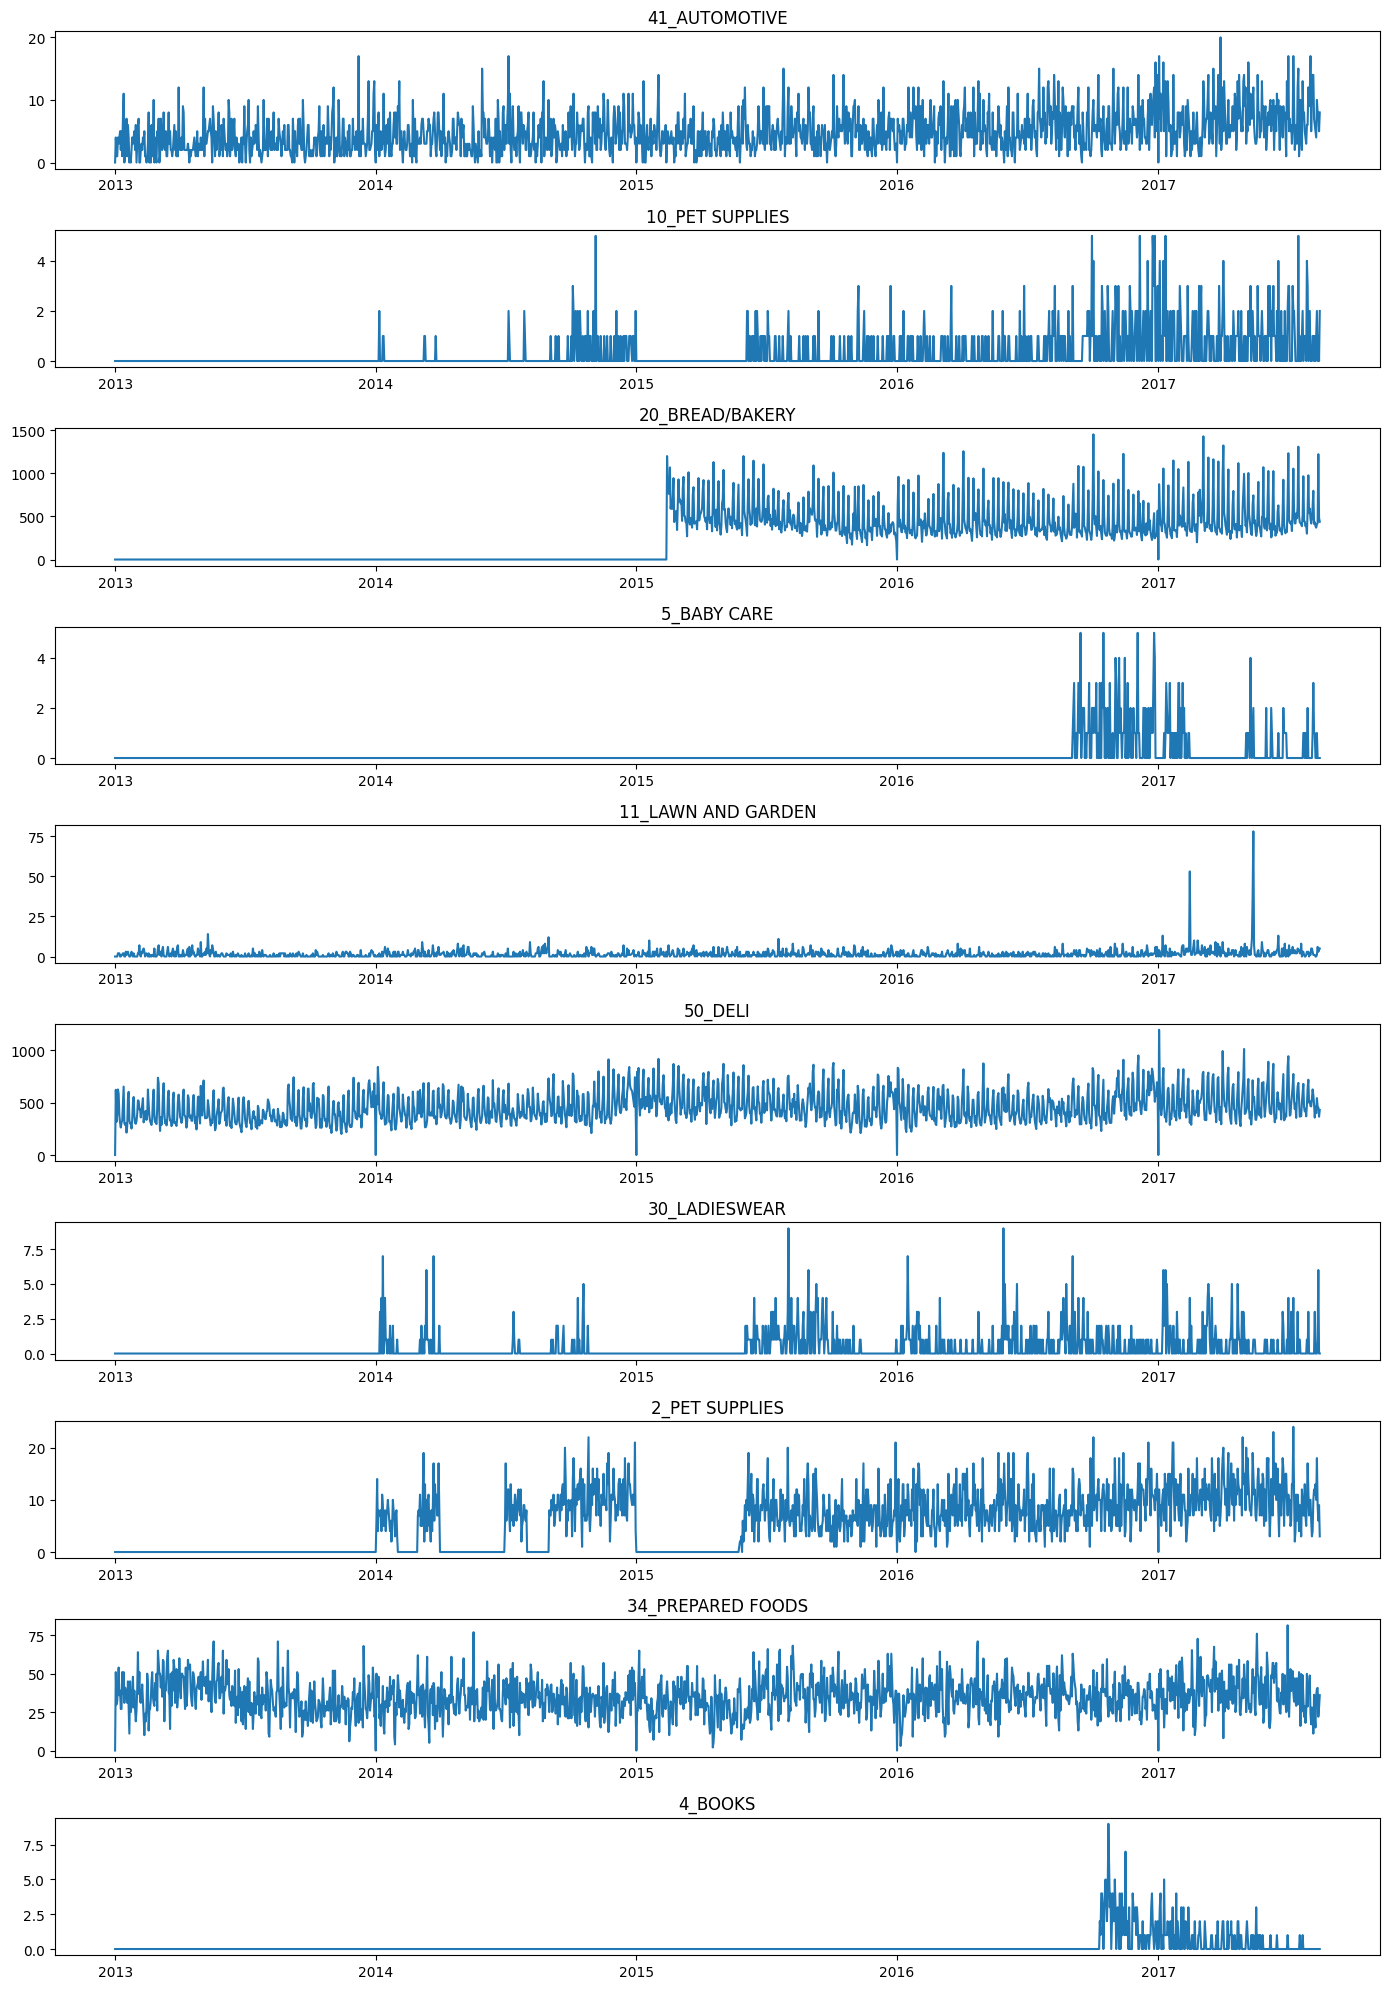

In [20]:
# Plot a few series to see patterns
fix, axes = plt.subplots(10, 1, figsize=(14, 20))
sample_ids = df['unique_id'].sample(n=10, random_state=1)
for uid, ax in zip(sample_ids, axes):
    subset = df[df['unique_id'] == uid]
    ax.plot(subset['ds'], subset['y'])
    ax.set_title(uid)
plt.tight_layout()
plt.savefig('eda_sample_series.png')
plt.show()

In [21]:
# Top 10 intermittent series
intermittent = df.groupby('unique_id')['y'].apply(lambda x: (x == 0).mean())
print(f"\n Top 10 most intermittent series:")
print(intermittent.sort_values(ascending=False).head(10))


 Top 10 most intermittent series:
unique_id
9_BOOKS               1.0
54_LAWN AND GARDEN    1.0
54_BOOKS              1.0
54_LADIESWEAR         1.0
11_BOOKS              1.0
10_BOOKS              1.0
17_BOOKS              1.0
16_BOOKS              1.0
25_LADIESWEAR         1.0
28_BOOKS              1.0
Name: y, dtype: float64


# StatsForecast Baseline

In [22]:
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    AutoCES,
    CrostonOptimized, # For intermittent demand
    SeasonalNaive, 
    HistoricAverage
)

## Data Subsetting and Train-Test Split

In [23]:
print(df['unique_id'].nunique())

1782


In [24]:
# SUBSET first
subset_categories = ['1_BEVERAGES', '34_PREPARED FOODS', '8_CLEANING', '33_DAIRY', '10_GROCERY I']

In [25]:
df_sample = df[df['unique_id'].isin(subset_categories)].copy()

In [26]:
# Split: last 16 days as test (Kaggle uses 16-day horizon)
# df_sample['ds'] = pd.to_datetime(df_sample['ds']).dt.normalize()
cutoff = df_sample['ds'].max() - pd.Timedelta(days=16)
train_df = df_sample[df_sample['ds'] <= cutoff]
test_df = df_sample[df_sample['ds'] > cutoff]

In [27]:
print(train_df['ds'].max(), test_df['ds'].min())

2017-07-30 00:00:00 2017-07-31 00:00:00


In [28]:
train_df.shape

(8340, 3)

In [29]:
train_df.groupby('unique_id').mean()

,ds,y
unique_id,,
10_GROCERY I,2015-04-16 07:57:24.604316416,2445.855020
1_BEVERAGES,2015-04-16 07:57:24.604316416,1583.754796
33_DAIRY,2015-04-16 07:57:24.604316416,384.465827
34_PREPARED FOODS,2015-04-16 07:57:24.604316416,35.011509
8_CLEANING,2015-04-16 07:57:24.604316416,1262.065947


In [30]:
test_df.shape

(80, 3)

## Model Training and Forecast

In [31]:
# Define models

from statsforecast.utils import ConformalIntervals # This allow to calculate the Confidence intervals

intervals = ConformalIntervals(h=16, n_windows=2) # TODO: How this works.


models = [
    AutoARIMA(season_length=7, prediction_intervals=intervals),
    AutoETS(season_length=7, prediction_intervals=intervals),
    AutoCES(season_length=7, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=7, prediction_intervals=intervals), 
    HistoricAverage()
]

# Fit and forecast
sf = StatsForecast(
    models=models,
    freq='D', # Daily data
    n_jobs=-1, # Parallel
)


# Use .forecast() for speed (no fitted values stored)
forecasts = sf.forecast(df=train_df, h=16, level=[90])

In [32]:
print(forecasts.head(6))

      unique_id         ds    AutoARIMA  AutoARIMA-lo-90  AutoARIMA-hi-90  \
0  10_GROCERY I 2017-07-31  2569.534459      2136.986125      3002.082793   
1  10_GROCERY I 2017-08-01  2417.180103      2015.748619      2818.611588   
2  10_GROCERY I 2017-08-02  2156.179594      1453.371468      2858.987720   
3  10_GROCERY I 2017-08-03  2118.120378      1355.450945      2880.789812   
4  10_GROCERY I 2017-08-04  2085.035325      1197.476023      2972.594628   
5  10_GROCERY I 2017-08-05  3080.786735      2784.339821      3377.233649   

       AutoETS  AutoETS-lo-90  AutoETS-hi-90          CES    CES-lo-90  \
0  2556.030790    2210.074949    2901.986631  2477.989410  2104.997354   
1  2404.898036    1699.168538    3110.627533  2458.168518  2010.930013   
2  2107.988113    1103.192733    3112.783493  2158.820480  1387.308097   
3  2057.973883    1032.230578    3083.717188  2131.527809  1309.742735   
4  2007.584936     816.709761    3198.460111  2067.917534  1124.126524   
5  3051.338191  

## Evaluation

In [33]:
test_df.columns

Index(['unique_id', 'ds', 'y'], dtype='object')

In [34]:
# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

eval_df = test_df.merge(forecasts.reset_index(), on=['unique_id', 'unique_id'])

model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [35]:
model_cols

['AutoARIMA',
 'AutoETS',
 'CES',
 'CrostonOptimized',
 'SeasonalNaive',
 'HistoricAverage']

In [36]:
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

In [37]:
results = []
for uid in subset_categories:
    mask = eval_df['unique_id'] == uid
    for model in model_cols:
        mae = mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model])
        rmse = np.square(mean_squared_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model]))
        results.append({'unique_id': uid, 'model': model, 'MAE': mae, 'RMSE': rmse})

results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.pivot_table(index='model', values=['MAE', 'RMSE'], aggfunc='mean').round(2))

best = results_df.loc[results_df.groupby('unique_id')['MAE'].idxmin()]
print("\n=== Best Model per Series ===")
print(best[['unique_id', 'model', 'MAE']])
        

## Cross-Validation

In [38]:
# StatForecast has built-in time series cross-validation

crossval = sf.cross_validation(
    df=df_sample,
    h=16,
    step_size=16, # Non-overlapping windows
    n_windows=3, # 3 folds
    level=[90],
)
print(crossval.head())

In [39]:
print("\n=== MAE ===")

for model in model_cols:
    mae = mean_absolute_error(crossval['y'], crossval[model])
    print(f"{model}: CV MAE = {mae:.2f}")
print("\n=== RMSE ===")
for model in model_cols:
    rmse = np.sqrt(mean_squared_error(crossval['y'], crossval[model]))
    print(f"{model}: CV MAE = {rmse:.2f}")

## Forecast Visualization

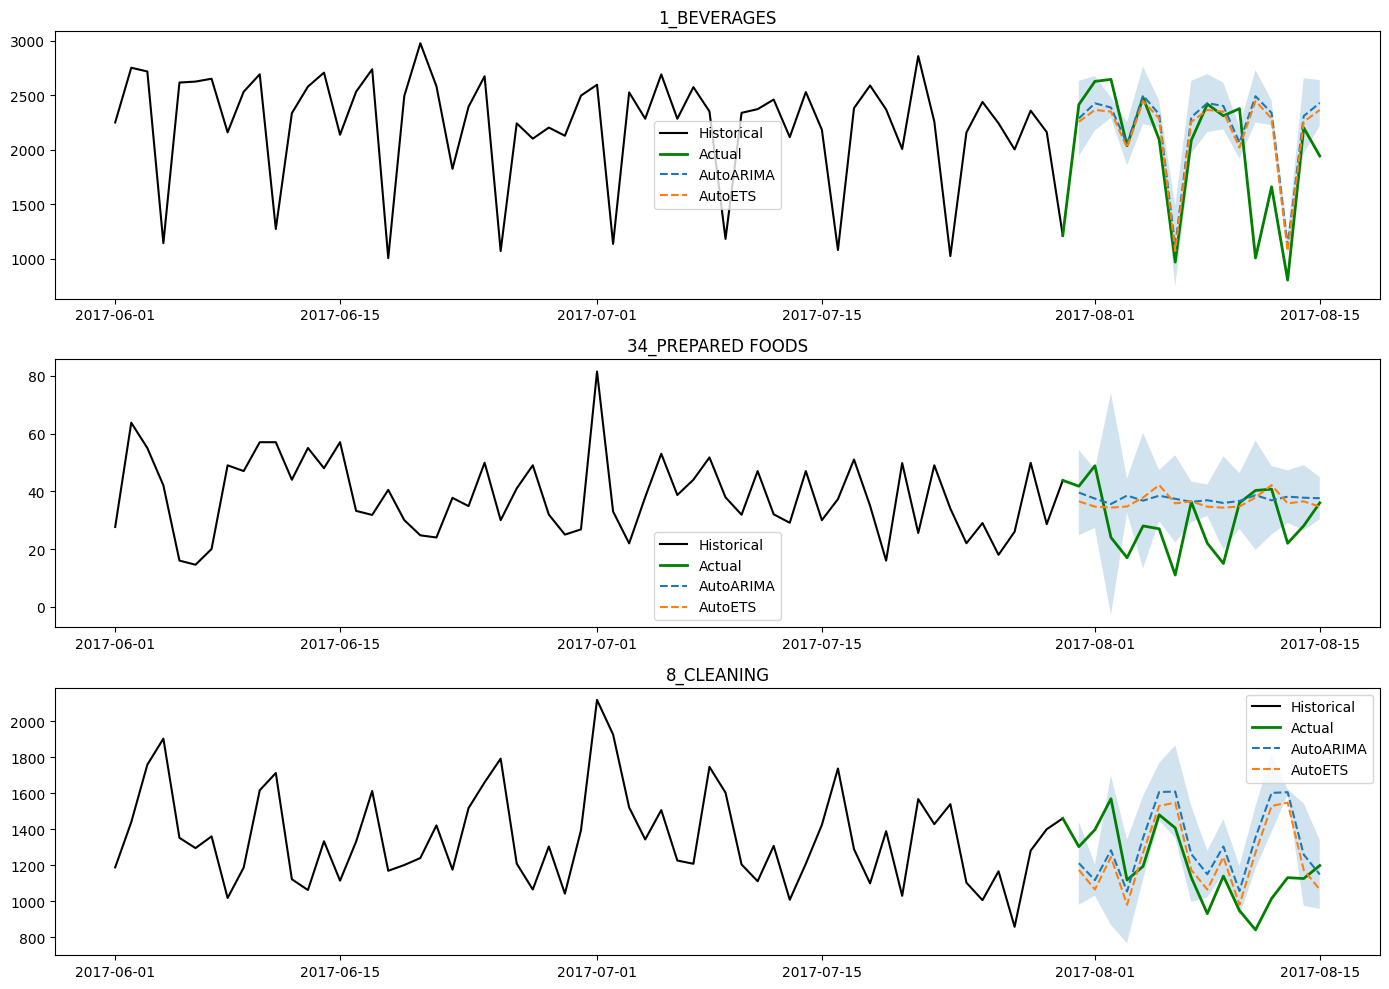

In [40]:
# Plot forecasts vs actual for 2-3 series
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in test period
    actual = test_df[test_df['unique_id'] == uid]
    actual = pd.concat([train_df[train_df['unique_id'] == uid].tail(1), actual])
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = forecasts.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['AutoARIMA'], label='AutoARIMA', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['AutoETS'], label='AutoETS', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

# Stretch Goals (if time allows)

- [ ] Add oil.csv as exogenous variable to AutoARIMA
- [ ] Try NeuralForecast: NHITS, PatchTST on same data
- [ ] Add MLflow tracking for experiment logging
- [ ] Hierarchical forecasting: store-level → family-level reconciliation

# Exogenous Variables: Oil Price

## Data Loading

In [41]:
oil_df = pd.read_csv(path + '/oil.csv', parse_dates=['date'])

In [42]:
print(f"{oil_df.head(5)}", f"\n {oil_df.tail(5)}")

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20 
            date  dcoilwtico
1213 2017-08-25       47.65
1214 2017-08-28       46.40
1215 2017-08-29       46.46
1216 2017-08-30       45.96
1217 2017-08-31       47.26


## Missing Values

In [43]:
oil_df.isna().sum()

date           0
dcoilwtico    43
dtype: int64

In [44]:
oil_df = oil_df.ffill()


In [45]:
oil_df.isna().sum()

date          0
dcoilwtico    1
dtype: int64

In [46]:
oil_df = oil_df.rename(columns={'dcoilwtico': 'oil_price'})

## Merge with Training and Test Data

In [47]:
exo_train_df = train_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [48]:
exo_train_df.isna().sum()

unique_id       0
ds              0
y               0
oil_price    2390
dtype: int64

In [49]:
exo_test_df = test_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [50]:
exo_test_df.isna().sum()

unique_id     0
ds            0
y             0
oil_price    20
dtype: int64

In [51]:
exo_test_df[exo_test_df['oil_price'].isna()]

,unique_id,ds,y,oil_price
25,1_BEVERAGES,2017-08-05,2093.000,NaN
26,10_GROCERY I,2017-08-05,3428.000,NaN
27,33_DAIRY,2017-08-05,459.000,NaN
28,34_PREPARED FOODS,2017-08-05,27.000,NaN
29,8_CLEANING,2017-08-05,1480.000,NaN
30,1_BEVERAGES,2017-08-06,968.000,NaN
31,10_GROCERY I,2017-08-06,3525.000,NaN
32,33_DAIRY,2017-08-06,574.000,NaN
33,34_PREPARED FOODS,2017-08-06,11.000,NaN
34,8_CLEANING,2017-08-06,1407.000,NaN


In [52]:
# Front and back fill with valid values after left join.
exo_test_df['oil_price'] = exo_test_df['oil_price'].ffill().bfill()
exo_train_df['oil_price'] = exo_train_df['oil_price'].ffill().bfill()

In [53]:
exo_train_df.isna().sum()

unique_id    0
ds           0
y            0
oil_price    0
dtype: int64

In [54]:
print(exo_test_df.shape, test_df.shape)
print(exo_test_df.columns)

(80, 4) (80, 3)
Index(['unique_id', 'ds', 'y', 'oil_price'], dtype='object')


## Model Training and Forecast

In [55]:
# Define models

from statsforecast.utils import ConformalIntervals # This allow to calculate the Confidence intervals

intervals = ConformalIntervals(h=16, n_windows=2) # TODO: How this works.


models = [
    AutoARIMA(season_length=7, prediction_intervals=intervals),
    AutoETS(season_length=7, prediction_intervals=intervals),
    AutoCES(season_length=7, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=7, prediction_intervals=intervals), 
    HistoricAverage()
]

# Fit and forecast
sf = StatsForecast(
    models=models,
    freq='D', # Daily data
    n_jobs=-1, # Parallel
)


# Use .forecast() for speed (no fitted values stored)
forecasts = sf.forecast(df=exo_train_df, h=16, level=[90], X_df=exo_test_df[['unique_id', 'ds', 'oil_price']])

## Evaluation

In [56]:
eval_df = exo_test_df.merge(forecasts.reset_index(), on=['unique_id', 'unique_id'])

In [57]:
eval_df

,unique_id,ds_x,y,oil_price,index,ds_y,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,AutoETS,...,CES-hi-90,CrostonOptimized,CrostonOptimized-lo-90,CrostonOptimized-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90
0,1_BEVERAGES,2017-07-31,2414.0,50.21,16,2017-07-31,2220.700506,1881.030115,2560.370896,2255.710118,...,2610.067157,2050.464672,1973.004261,2127.925084,2158.0,1874.40,2441.60,1583.754796,387.552934,2779.956658
1,1_BEVERAGES,2017-07-31,2414.0,50.21,17,2017-08-01,2424.403067,2184.704472,2664.101663,2364.571929,...,2591.640561,2050.464672,997.412268,3103.517076,2438.0,2336.00,2540.00,1583.754796,387.552934,2779.956658
2,1_BEVERAGES,2017-07-31,2414.0,50.21,18,2017-08-02,2356.148914,2253.598849,2458.698978,2349.496848,...,2460.015815,2050.464672,1686.067904,2414.861440,2242.0,2169.25,2314.75,1583.754796,387.552934,2779.956658
3,1_BEVERAGES,2017-07-31,2414.0,50.21,19,2017-08-03,2027.360325,1838.706143,2216.014506,2019.007641,...,2249.996652,2050.464672,1106.572525,2994.356819,2002.0,1807.80,2196.20,1583.754796,387.552934,2779.956658
4,1_BEVERAGES,2017-07-31,2414.0,50.21,20,2017-08-04,2472.148205,2202.412031,2741.884380,2446.621121,...,2739.192558,2050.464672,1747.367904,2353.561440,2358.0,2102.95,2613.05,1583.754796,387.552934,2779.956658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,8_CLEANING,2017-08-15,1198.0,47.57,75,2017-08-11,1353.284324,1181.764323,1524.804324,1270.641195,...,1499.500120,1289.189401,1120.261180,1458.117622,1281.0,1160.40,1401.60,1262.065947,811.681687,1712.450207
1276,8_CLEANING,2017-08-15,1198.0,47.57,76,2017-08-12,1600.393045,1383.782953,1817.003137,1528.913982,...,1789.817018,1289.189401,844.511180,1733.867622,1400.0,1265.60,1534.40,1262.065947,811.681687,1712.450207
1277,8_CLEANING,2017-08-15,1198.0,47.57,77,2017-08-13,1604.145067,1587.690804,1620.599330,1547.446129,...,1657.607361,1289.189401,1233.461180,1344.917622,1460.0,1397.50,1522.50,1262.065947,811.681687,1712.450207
1278,8_CLEANING,2017-08-15,1198.0,47.57,78,2017-08-14,1258.927677,975.680168,1542.175187,1174.055217,...,1520.652202,1289.189401,991.837844,1586.540958,1103.0,783.85,1422.15,1262.065947,811.681687,1712.450207


In [58]:
# MAE
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

243.78565022271346


In [59]:
results = []

for uid in subset_categories:
    mask = eval_df['unique_id'] == uid
    for model in model_cols:
        mae = mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model])
        rsme = np.sqrt(mean_squared_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, model]))
        results.append({'unique_id': uid, 'model': model, 'MAE': mae, 'RSME': rsme})


results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.pivot_table(index='model', values=['MAE', 'RSME'], aggfunc='mean').round(2))

best = results_df.loc[results_df.groupby('unique_id')['MAE'].idxmin()]
print("\n=== Best mode per Serioes ===")
print(best[['unique_id', 'model', 'MAE']])
        


=== Model Comparison ===
                     MAE    RSME
model                           
AutoARIMA         287.70  368.24
AutoETS           289.60  369.97
CES               282.54  362.80
CrostonOptimized  240.90  296.35
HistoricAverage   288.45  326.60
SeasonalNaive     317.82  397.78

=== Best mode per Serioes ===
            unique_id             model         MAE
27       10_GROCERY I  CrostonOptimized  475.576349
3         1_BEVERAGES  CrostonOptimized  439.633832
21           33_DAIRY  CrostonOptimized   84.750000
9   34_PREPARED FOODS  CrostonOptimized    9.741469
17         8_CLEANING   HistoricAverage  184.649730


## Cross-Validation with Exogenous Variables

In [60]:
df_oily = df_sample.merge(oil_df, how='left', left_on='ds', right_on='date')

In [61]:
df_oily = df_oily.drop(columns=['date'])

In [62]:
df_oily = df_oily.ffill().bfill()

In [63]:
# StatForecast has built-in time series cross-validation

crossval_exogen = sf.cross_validation(
    df=df_oily,
    h=16,
    step_size=16, # Non-overlapping windows
    n_windows=3, # 3 folds
    level=[90],
)
print(crossval_exogen.head())

      unique_id         ds     cutoff       y    AutoARIMA  AutoARIMA-lo-90  \
0  10_GROCERY I 2017-06-29 2017-06-28  1937.0  1857.740840      1403.101073   
1  10_GROCERY I 2017-06-30 2017-06-28  2473.0  2005.709117      1734.405774   
2  10_GROCERY I 2017-07-01 2017-06-28  3953.0  3156.064083      2769.545228   
3  10_GROCERY I 2017-07-02 2017-06-28  3783.0  2935.137668      2251.501742   
4  10_GROCERY I 2017-07-03 2017-06-28  3599.0  2591.021956      2147.593564   

   AutoARIMA-hi-90      AutoETS  AutoETS-lo-90  AutoETS-hi-90  ...  \
0      2312.380608  1673.130670    1242.825943    2103.435396  ...   
1      2277.012460  1691.170779    1259.280473    2123.061084  ...   
2      3542.582937  2793.803948    2020.172186    3567.435710  ...   
3      3618.773594  2582.000365    1521.387901    3642.612829  ...   
4      3034.450348  2223.223106    1522.952749    2923.493463  ...   

     CES-hi-90  CrostonOptimized  CrostonOptimized-lo-90  \
0  2193.506814        2268.76914            

In [64]:
model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [65]:
print("\n=== MAE ===")

for model in model_cols:
    mae = mean_absolute_error(crossval_exogen['y'], crossval_exogen[model])
    print(f"{model}: CV MAE: {mae:.2f}")

print("\n=== RMSE ===")

for model in model_cols:
    rmse = np.sqrt(mean_squared_error(crossval_exogen['y'], crossval_exogen[model]))
    print(f"{model}: CV RMSE:{rmse:.2f}")


=== MAE ===
AutoARIMA: CV MAE: 171.58
AutoETS: CV MAE: 181.76
CES: CV MAE: 168.93
CrostonOptimized: CV MAE: 232.36
SeasonalNaive: CV MAE: 191.77
HistoricAverage: CV MAE: 297.38

=== RMSE ===
AutoARIMA: CV RMSE:279.51
AutoETS: CV RMSE:304.49
CES: CV RMSE:279.17
CrostonOptimized: CV RMSE:381.46
SeasonalNaive: CV RMSE:326.49
HistoricAverage: CV RMSE:444.68


## Visualization

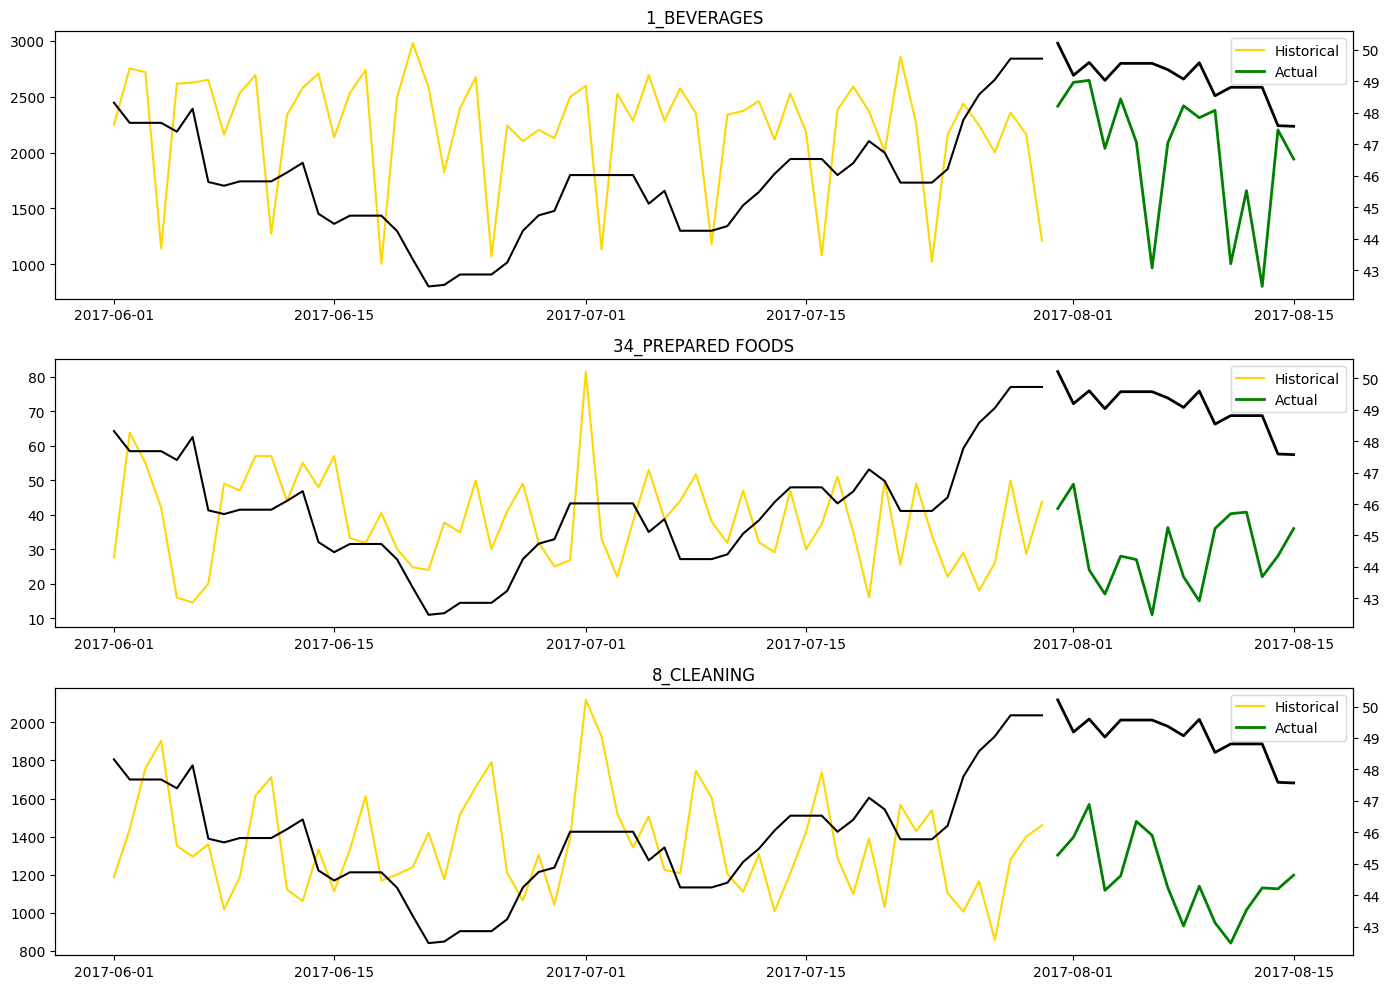

In [66]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))

for ax, uid in zip(axes, subset_categories[:3]):

    # Historical
    hist = exo_train_df[exo_train_df['unique_id'] == uid].tail(60)
    ax2 = ax.twinx()
    ax2.plot(hist['ds'], hist['oil_price'], label='Oil Price', color='black')
    ax.plot(hist['ds'], hist['y'], label='Historical', color='gold')


    # Actual in test period
    actual = exo_test_df[exo_test_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual',  color='green', linewidth=2)
    ax2.plot(actual['ds'], actual['oil_price'], label='Oil_price',  color='black', linewidth=2)
    
    
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_with_oil_price_comparison.png', dpi=150)
plt.show()
    

# NeuralForecast

## Setup

In [67]:
import logging
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, RNN

In [68]:
logging.getLogger('pytorch_lighting').setLevel(logging.ERROR)

## Model Training

In [69]:
train_df.head(1)

,unique_id,ds,y
3,1_BEVERAGES,2013-01-01,0.0


In [70]:
%%capture
horizon = 16

models = [
    LSTM(input_size=2 * horizon,
         h=horizon,
         max_steps=500,
         scaler_type='standard',
         encoder_hidden_size=64,
         decoder_hidden_size=64,
        ),
    
    GRU(input_size=2 * horizon,
         h=horizon,
         max_steps=500,
         scaler_type='standard',
         encoder_hidden_size=64,
         decoder_hidden_size=64,
        ),
    RNN(input_size=2 * horizon,
         h=horizon,
         max_steps=500,
         scaler_type='standard',
         encoder_hidden_size=64,
         decoder_hidden_size=64,
        ),
    
]

nf = NeuralForecast(models=models, freq='D')

nf.fit(df=train_df)



Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 50.4 K | train
4 | mlp_decoder  | MLP           | 4.2 K  | train
-------------------------------------------------------
54.7 K    Trainable params
0         Non-trainable params
54.7 K    Total params
0.219     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
---------

## Prediction and Evaluation

In [71]:
y_hat = nf.predict(df=test_df)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/on1link/Applications/projects/store_sales/store_sales_forecasting/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |                                                                  | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                  | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                  | 0/? [00:00<?, ?it/s]

In [72]:
y_hat.head(10)

,unique_id,ds,LSTM,GRU,RNN
0,10_GROCERY I,2017-08-16,2838.248047,2569.970215,3018.737305
1,10_GROCERY I,2017-08-17,2848.813232,2608.767334,2987.947266
2,10_GROCERY I,2017-08-18,2841.127930,2645.809082,2946.972168
3,10_GROCERY I,2017-08-19,2786.911865,2731.501465,2737.549316
4,10_GROCERY I,2017-08-20,2673.247070,2833.215332,2673.172119
5,10_GROCERY I,2017-08-21,3178.321777,3145.425781,3235.909180
6,10_GROCERY I,2017-08-22,3346.356689,3088.681396,3044.328613
7,10_GROCERY I,2017-08-23,3135.028076,2882.987549,2892.433105
8,10_GROCERY I,2017-08-24,2918.581299,2756.263672,2836.900879
9,10_GROCERY I,2017-08-25,2817.638916,2696.756592,2635.070801


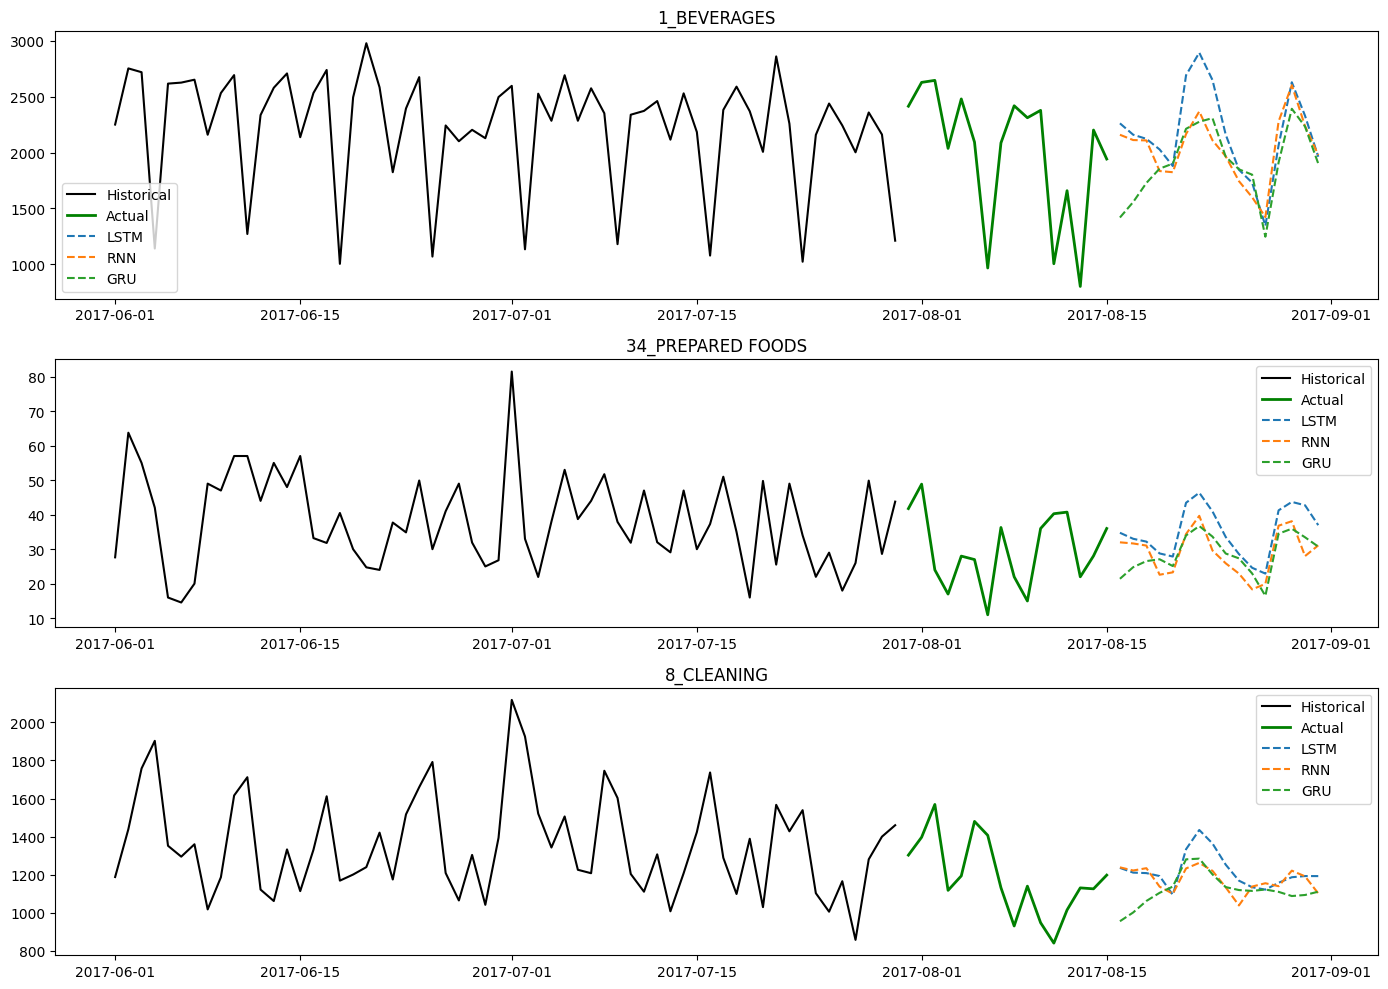

In [73]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in test period
    actual = test_df[test_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = y_hat.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['LSTM'], label='LSTM', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['RNN'], label='RNN', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['GRU'], label='GRU', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()